In [3]:
import pandas as pd

In [9]:
df = pd.read_csv("../../course_assignments/homework8/state_data.csv")
print(df.shape)
# 52 rows and 4 columns

print(df.head())
print(df.tail())
# The columns represent the state acronym, the states latitude adn longitude, and the full state name in order
# The first state is Alaska and the last state is Wyoming
# There is 208 entries in total
# There are more than 50 because it must be counting Puerto Rico and D.C as states as well


(52, 4)
  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [11]:
median_lat = df["latitude"].median()
median_lon = df["longitude"].median()
df["abs_lat_dist"] = abs(df["latitude"] - median_lat)
df["abs_lon_dist"] = abs(df["longitude"] - median_lon)
print(df.shape)
# 52 rows and 6 columns

closest_lat = df.loc[df["abs_lat_dist"].idxmin()]
farthest_lat = df.loc[df["abs_lat_dist"].idxmax()]
closest_lon = df.loc[df["abs_lon_dist"].idxmin()]
farthest_lon = df.loc[df["abs_lon_dist"].idxmax()]
print(f"State closest to median latitude: {closest_lat['state']} ({closest_lat['abs_lat_dist']:.2f}° away)")
print(f"State farthest from median latitude: {farthest_lat['state']} ({farthest_lat['abs_lat_dist']:.2f}° away)")
print(f"State closest to median longitude: {closest_lon['state']} ({closest_lon['abs_lon_dist']:.2f}° away)")
print(f"State farthest from median longitude: {farthest_lon['state']} ({farthest_lon['abs_lon_dist']:.2f}° away)")

(52, 6)
State closest to median latitude: CO (0.11° away)
State farthest from median latitude: AK (24.15° away)
State closest to median longitude: IL (0.31° away)
State farthest from median longitude: HI (66.57° away)


In [12]:
df.describe()
# I found the dataframe.describe function on the 10 minutes to pandas under the user guide tab past the viewing data section.
# It analyzes both numeric and object series and qives quick summary of the statistics of the data. Sojme include the std, min and max, the percentiles, the mean, and the count

,latitude,longitude,abs_lat_dist,abs_lon_dist
count,52.000000,52.000000,52.000000,52.000000
mean,39.153437,-92.824719,4.815714,14.535330
std,6.967697,19.431647,4.998411,13.280351
min,18.220833,-155.665857,0.114536,0.305330
25%,35.438381,-102.009600,1.564952,6.037732
50%,39.435516,-89.093198,3.890968,11.903743
75%,43.220246,-78.291302,6.133912,17.832342
max,63.588753,-66.590149,24.153237,66.572659


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
crashes = sns.load_dataset("car_crashes")
crashes = crashes.dropna(axis=1)
print(crashes.shape)
# The shape is 51, 8 and there is 51 rows and 8 columns. 
print("First five rows:")
display(crashes.head())
print("\nLast five rows:")
display(crashes.tail())
print(crashes.columns.tolist())
# Total crashes per billion miles, percentage involving speeding, percentage involving alcohol, percentage where driver wasn't distracted, percentage where driver was in no previous accidents, average car insurance premium, average insurance loss incurred, state abbreviation.

(51, 8)
First five rows:


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA



Last five rows:


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
46,12.7,2.413,3.429,11.049,11.176,768.95,153.72,VA
47,10.6,4.452,3.498,8.692,9.116,890.03,111.62,WA
48,23.8,8.092,6.664,23.086,20.706,992.61,152.56,WV
49,13.8,4.968,4.554,5.382,11.592,670.31,106.62,WI
50,17.4,7.308,5.568,14.094,15.660,791.14,122.04,WY


['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses', 'abbrev']


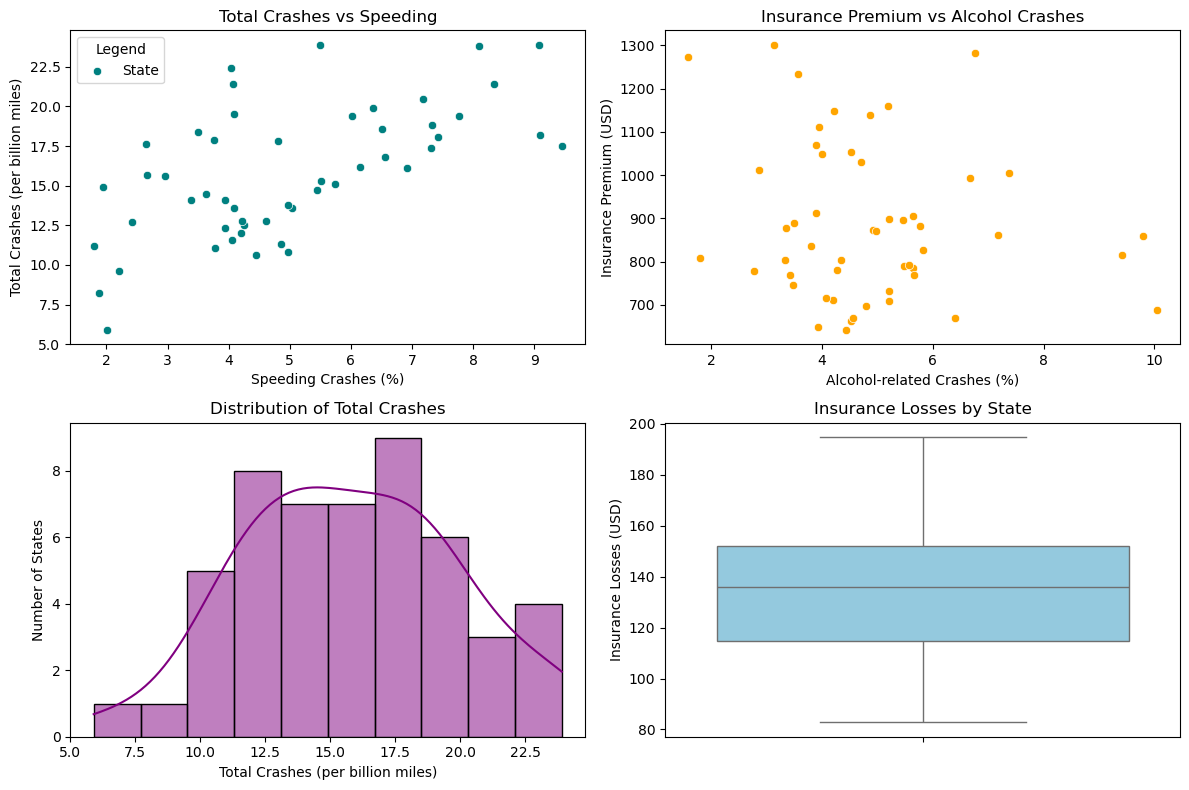

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Scatter plot (total vs speeding)
sns.scatterplot(data=crashes, x="speeding", y="total", ax=axes[0, 0], color="teal", label="State")
axes[0, 0].set_title("Total Crashes vs Speeding")
axes[0, 0].set_title("Total Crashes vs Speeding")
axes[0, 0].set_xlabel("Speeding Crashes (%)")
axes[0, 0].set_ylabel("Total Crashes (per billion miles)")
axes[0, 0].legend(title="Legend")

# Top-right: Scatter plot (alcohol vs ins_premium)
sns.scatterplot(data=crashes, x="alcohol", y="ins_premium", ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Insurance Premium vs Alcohol Crashes")
axes[0, 1].set_xlabel("Alcohol-related Crashes (%)")
axes[0, 1].set_ylabel("Insurance Premium (USD)")

# Bottom-left: Histogram (total crashes)
sns.histplot(data=crashes, x="total", bins=10, kde=True, ax=axes[1, 0], color="purple")
axes[1, 0].set_title("Distribution of Total Crashes")
axes[1, 0].set_xlabel("Total Crashes (per billion miles)")
axes[1, 0].set_ylabel("Number of States")

# Bottom-right: Boxplot (insurance losses)
sns.boxplot(data=crashes, y="ins_losses", ax=axes[1, 1], color="skyblue")
axes[1, 1].set_title("Insurance Losses by State")
axes[1, 1].set_ylabel("Insurance Losses (USD)")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()

In [ ]:
# The top left plot shows the relationship between the percentage of speeding-related crashes and the total number of crashes per billion miles. States with higher speeding percentages tend to have higher total crash rates, though some states deviate from this trend, suggesting other contributing factors to crashes.
# The top right plot explores whether alcohol-related crashes are associated with higher insurance premiums. While there is a mild correlation, the data indicate that premiums are influenced by multiple factors beyond alcohol-related incidents.
# The bottom left histogram illustrates the distribution of total crashes across all states. Most states cluster around a moderate crash rate, with a few states showing unusually high or low values, highlighting potential outliers.
# The bottom right boxplot depicts the variability of insurance losses across states. It reveals that while most states have losses within a typical range, a few outliers experience significantly higher losses, emphasizing differences in claim frequency or severity.